# VIP-SLAP2 all-modality data crunching notebook

This notebook is a deployment notebook for session-level preprocessing, QC, and event extraction across the VIP synaptic dynamics dataset.

It is intended to provide a processing entry point for:

- behavior / HARP / photodiode QC
- glutamate SLAP2 QC and image/change/omission extraction
- calcium QC and extraction for paired red calcium channels
- voltage QC and event extraction using the new voltage asset model


In [1]:
# Notebook display + autoreload
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib notebook

## 1. Configure paths and processing switches

Adjust the path variables and `target_mice` list before running. The `RUN_*` switches let you rerun individual stages without editing the main loop.


In [12]:
# ---------------------------------------------------------------------
# Local repository / data paths
# ---------------------------------------------------------------------
# If running from inside the repo, this can usually stay as None.
# If imports fail, set REPO_ROOT to your local clone, e.g.
# REPO_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis")
REPO_ROOT = None

if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

# Optional local copy of the summary table. The registry discovers sessions from BASE_PATH;
# this file is only useful for ad hoc inspection or manual cross-checks.
SUMMARY_XLSX = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx")

# ---------------------------------------------------------------------
# Session selection
# ---------------------------------------------------------------------
target_mice = [
    826031,
    826032,
]

EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
PARADIGMS = ["change_detection_passive"]

# ---------------------------------------------------------------------
# Execution controls
# ---------------------------------------------------------------------
RUN_BEHAVIOR = True
# Set these to True only for modalities you want to regenerate.
# For voltage re-extraction after the epoch-aware MATLAB/Python updates, keep
# behavior + voltage enabled and leave glutamate/calcium disabled unless you
# intentionally want to recompute those products too.
RUN_GLUTAMATE_QC = False
RUN_GLUTAMATE_EXTRACTION = False
RUN_CALCIUM_QC = False
RUN_CALCIUM_EXTRACTION = False
RUN_VOLTAGE_QC = True
RUN_VOLTAGE_EXTRACTION = True

# Recompute outputs even if they already exist.
# Re-run behavior at least once after the DI3 pulse-train epoch update so that
# qc/behavior/imaging_epochs.csv and pulse diagnostics are refreshed.
OVERWRITE_BEHAVIOR = True
OVERWRITE_QC = True
OVERWRITE_EXTRACTION = True

# Development controls for expensive steps.
MAKE_PLOTS = False
MAX_SESSION_MINUTES_CALCIUM = None       # e.g. 15 for development; None for full session
MAX_TRIALS_FOR_VOLTAGE_QC = None        # e.g. 10 for development; None for full QC

# If True, behavior failures prevent physiology extraction.
REQUIRE_BEHAVIOR_READY = True

# If True, do not execute processing calls; only build assets/status table.
DRY_RUN = False

## 2. Import pipeline entry points

These imports define the expected public API for the processing pipeline.


In [4]:
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.behavior.preprocess import process_behavior_session

from vip_slap2_analysis.common.qc import run_session_synapse_qc
from vip_slap2_analysis.glutamate.extraction import process_glutamate_extraction

from vip_slap2_analysis.calcium.qc import run_calcium_qc
from vip_slap2_analysis.calcium.extraction import process_calcium_extraction

from vip_slap2_analysis.voltage.qc import run_voltage_qc
from vip_slap2_analysis.voltage.extraction import (
    process_voltage_extraction,
    compute_voltage_roi_transform_from_asset,
    load_voltage_roi_transform_h5,
)
from vip_slap2_analysis.voltage.postprocess import load_voltage_summary_from_asset
from vip_slap2_analysis.common.epoch_alignment import load_epoch_dataframe_from_asset

# Guard against accidentally importing an older editable install / stale kernel.
# The voltage alignment patch added these kwargs. Restart the kernel if this fails.
import inspect
_voltage_extraction_sig = inspect.signature(process_voltage_extraction)
for _required_kw in ["timebase_strategy", "max_timebase_error_sec", "default_sample_rate_hz"]:
    assert _required_kw in _voltage_extraction_sig.parameters, (
        "process_voltage_extraction is missing the voltage timebase update kwarg "
        f"{_required_kw!r}. Restart the kernel and confirm the patched repo is on sys.path."
    )

_voltage_roi_transform_sig = inspect.signature(compute_voltage_roi_transform_from_asset)
for _required_kw in ["timebase_strategy", "max_timebase_error_sec", "default_sample_rate_hz"]:
    assert _required_kw in _voltage_roi_transform_sig.parameters, (
        "compute_voltage_roi_transform_from_asset is missing the voltage timebase update kwarg "
        f"{_required_kw!r}. Restart the kernel and confirm the patched repo is on sys.path."
    )

_behavior_sig = inspect.signature(process_behavior_session)
for _required_kw in [
    "epoch_detection_method",
    "pulse_gap_factor",
    "pulse_min_gap_s",
    "pulse_min_pulses",
    "pulse_min_duration",
]:
    assert _required_kw in _behavior_sig.parameters, (
        "process_behavior_session is missing the DI3 pulse-train epoch kwarg "
        f"{_required_kw!r}. Restart the kernel and confirm the patched repo is on sys.path."
    )

print("Epoch-aware behavior + voltage updates detected in imported repo.")


Epoch-aware behavior + voltage updates detected in imported repo.


## 3. Define modality-specific metadata and extraction settings

The event windows are kept explicit so behavior, glutamate, calcium, and voltage use the same conceptual event definitions.


In [5]:
# Behavior alignment / epoch metadata
BEHAVIOR_METADATA = {
    "epochs_mode": "continuous",
    "prepost_sec": {
        "image_identity": (0.25, 0.750),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# DI3 pulse-train epoch detection settings. These are passed explicitly so the
# notebook records the choices used for all modalities.
BEHAVIOR_EPOCH_KWARGS = {
    "epoch_detection_method": "pulse_train",
    "pulse_gap_factor": 10.0,
    "pulse_min_gap_s": 0.5,
    "pulse_min_pulses": 10,
    "pulse_min_duration": 30.0,
}

# Glutamate and calcium are currently treated as frame-rate data.
FRAME_RATE_HZ = 200.0

GLUTAMATE_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.50),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

CALCIUM_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.750),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# Voltage: resolve the real SLAP2 line/sample rate from the voltage summary metadata.
# Important: leave this as None. Passing 10_800.0 explicitly bypasses metadata-derived
# lineRateHz and can reintroduce event-alignment drift in trial-based voltage sessions.
VOLTAGE_SAMPLE_RATE_HZ = None
VOLTAGE_DEFAULT_SAMPLE_RATE_HZ = 10_800.0

# For trial-based voltage acquisitions, auto-scaling maps the reconstructed sample stream
# onto the corrected behavior/imaging epoch only when the nominal reconstructed duration
# and behavior epoch duration disagree by more than VOLTAGE_MAX_TIMEBASE_ERROR_SEC.
VOLTAGE_TIMEBASE_STRATEGY = "auto"      # "auto", "sample_rate", or "epoch_scaled"
VOLTAGE_MAX_TIMEBASE_ERROR_SEC = 0.5

# Recommended first-pass voltage extraction signals:
# - dff_static_f0: most conservative for long slow oscillations/state dynamics
# - dff_robust_f0: useful default for event-aligned response/sequence analyses
VOLTAGE_TRACE_SIGNALS = [
    "dff_static_f0",
    "dff_robust_f0",
]

VOLTAGE_EXTRACTION_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "default_sample_rate_hz": VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
    # Resolved per-session below: trial for normal/multi-epoch sessions,
    # continuous for single large non-CYCLE outputs, auto as fallback.
    "trace_mode": "auto",
    "timebase_strategy": VOLTAGE_TIMEBASE_STRATEGY,
    "max_timebase_error_sec": VOLTAGE_MAX_TIMEBASE_ERROR_SEC,
    "use_roi_qc": True,
    "write_session_traces": True,
    "f0_percentile": 50.0,
    "robust_f0_bin_sec": 5.0,
    "robust_f0_smooth_sec": 180.0,
}

VOLTAGE_QC_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "default_sample_rate_hz": VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
    # Resolved per-session below.
    "trace_mode": "auto",
    "drop_discarded": True,
    "make_plots": MAKE_PLOTS,
    "max_trials_for_metrics": MAX_TRIALS_FOR_VOLTAGE_QC,
}


## 4. Resolve sessions and inspect discovered assets

The registry should now discover both conventional `SummaryLoCo*.mat` assets and voltage `dendriticVoltageSummary*.mat` / `dendriticVoltageTraces*.h5` assets via `SessionAssets.modality_assets`.


In [6]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions for target mice: {target_mice}")
display(process_df.head())

Found 19 candidate sessions for target mice: [826031, 826032]


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [7]:
def get_modality_asset(asset, modality, key):
    """Safely retrieve a modality asset from the generic asset model."""
    if hasattr(asset, "get_asset"):
        return asset.get_asset(modality, key)
    return None


def has_modality_asset(asset, modality, required_keys=("summary_mat",)):
    """Return True if required modality asset keys are present."""
    if hasattr(asset, "has_modality"):
        try:
            return bool(asset.has_modality(modality, {k: None for k in required_keys}))
        except TypeError:
            # In case the local helper signature differs from the generated draft.
            return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)
    return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)


def metadata_text(asset):
    """Concatenate metadata values into one lowercase string for lightweight modality heuristics."""
    meta = getattr(asset, "metadata", None) or {}
    parts = []
    for value in meta.values():
        if isinstance(value, (str, int, float)):
            parts.append(str(value))
    return " ".join(parts).lower()


def infer_modalities(asset):
    """Infer which processing branches should run for an asset.

    The asset model is the source of truth for voltage because voltage has distinct
    dendriticVoltageSummary/dendriticVoltageTraces files. Glutamate/calcium currently
    share the SummaryLoCo-style asset family, so metadata indicators are used as a
    lightweight heuristic.
    """
    meta = metadata_text(asset)

    has_voltage_files = has_modality_asset(asset, "voltage", ("summary_mat", "trace_h5"))
    voltage_by_indicator = any(tok in meta for tok in ["asap", "voltron", "voltage"])

    has_summary = getattr(asset, "summary_mat", None) is not None
    glutamate_by_indicator = any(tok in meta for tok in ["iglusnfr", "glutamate", "glusnfr"])
    calcium_by_indicator = any(tok in meta for tok in ["rcamp", "jrgeco", "gcamp", "camp", "calcium"])

    # Conservative defaults:
    # - run voltage only when voltage files are present
    # - run glutamate whenever a SummaryLoCo-style summary exists and the session is not voltage-only
    # - run calcium only when metadata indicates a calcium channel
    return {
        "behavior": True,
        "voltage": bool(has_voltage_files),
        "glutamate": bool(has_summary and (glutamate_by_indicator or not has_voltage_files)),
        "calcium": bool(has_summary and calcium_by_indicator),
        "voltage_by_indicator_without_files": bool(voltage_by_indicator and not has_voltage_files),
    }


def asset_summary_row(asset):
    mods = infer_modalities(asset)
    return {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "summary_mat": getattr(asset, "summary_mat", None),
        "voltage_summary_mat": get_modality_asset(asset, "voltage", "summary_mat"),
        "voltage_trace_h5": get_modality_asset(asset, "voltage", "trace_h5"),
        "bonsai_event_log_csv": getattr(asset, "bonsai_event_log_csv", None),
        "harp_dir": getattr(asset, "harp_dir", None),
        "photodiode_pkl": getattr(asset, "photodiode_pkl", None),
        **{f"run_{k}": v for k, v in mods.items()},
    }

asset_df = pd.DataFrame([asset_summary_row(a) for a in assets])
display(asset_df)

,subject_id,session_id,summary_mat,voltage_summary_mat,voltage_trace_h5,bonsai_event_log_csv,harp_dir,photodiode_pkl,run_behavior,run_voltage,run_glutamate,run_calcium,run_voltage_by_indicator_without_files
0,826031,826031_2026-01-30_15-04-02,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
1,826031,826031_2026-02-01_11-01-50,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
2,826031,826031_2026-02-02_10-23-53,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
3,826031,826031_2026-02-03_14-21-45,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
4,826031,826031_2026-02-04_12-15-34,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
5,826031,826031_2026-02-05_09-28-56,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
6,826031,826031_2026-02-06_10-21-20,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
7,826031,826031_2026-02-10_10-48-51,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
8,826031,826031_2026-02-11_12-42-21,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
9,826031,826031_2026-02-12_07-43-37,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False


## 5. Processing helpers

The main loop below records status for every stage. A failure in one stage is captured in the status table rather than stopping the entire batch.


In [8]:
def run_stage(stage_name, fn, *args, **kwargs):
    """Run one processing stage and capture status without killing the batch."""
    if DRY_RUN:
        return {"stage": stage_name, "status": "dry_run", "result": None, "error": None}

    try:
        result = fn(*args, **kwargs)
        status = getattr(result, "status", "ok")
        return {"stage": stage_name, "status": status, "result": result, "error": None}
    except Exception as exc:
        return {
            "stage": stage_name,
            "status": "error",
            "result": None,
            "error": "".join(traceback.format_exception_only(type(exc), exc)).strip(),
            "traceback": traceback.format_exc(),
        }


def append_record(records, asset, stage_result, extra=None):
    rec = {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "stage": stage_result.get("stage"),
        "status": stage_result.get("status"),
        "error": stage_result.get("error"),
    }
    if extra:
        rec.update(extra)
    records.append(rec)


def print_asset_header(asset):
    print("\n" + "=" * 100)
    print(f"SUBJECT: {asset.subject_id} | SESSION: {asset.session_id}")
    print("-" * 100)
    print("summary_mat:        ", getattr(asset, "summary_mat", None))
    print("voltage_summary:    ", get_modality_asset(asset, "voltage", "summary_mat"))
    print("voltage_trace_h5:   ", get_modality_asset(asset, "voltage", "trace_h5"))
    print("bonsai_event_log:   ", getattr(asset, "bonsai_event_log_csv", None))
    print("harp_dir:           ", getattr(asset, "harp_dir", None))
    print("photodiode_pkl:     ", getattr(asset, "photodiode_pkl", None))
    print("modalities:         ", infer_modalities(asset))
    print("=" * 100)



def resolve_voltage_trace_mode(asset, *, prefer_trial=True):
    """Choose the safest voltage trace mode for this asset.

    - normal CYCLE and multi-epoch voltage extractions should use trial mode
    - single large non-CYCLE extractions may only contain continuous datasets
    - auto is retained as a fallback if the reader cannot report modes
    """
    try:
        with load_voltage_summary_from_asset(asset, keep_open=True) as vs:
            modes = set(vs.available_trace_modes()) if hasattr(vs, "available_trace_modes") else set()
    except Exception as exc:
        print(f"Could not inspect voltage trace modes for {asset.session_id}: {exc!r}; using auto.")
        return "auto"

    if prefer_trial and "trial" in modes:
        return "trial"
    if "continuous" in modes:
        return "continuous"
    if "trial" in modes:
        return "trial"
    return "auto"


def voltage_extraction_kwargs_for_asset(asset):
    kwargs = dict(VOLTAGE_EXTRACTION_KWARGS)
    kwargs["trace_mode"] = resolve_voltage_trace_mode(asset)
    return kwargs


def voltage_qc_kwargs_for_asset(asset):
    kwargs = dict(VOLTAGE_QC_KWARGS)
    kwargs["trace_mode"] = resolve_voltage_trace_mode(asset)
    return kwargs


def print_voltage_epoch_status(asset):
    """Print quick voltage/behavior epoch status before expensive extraction."""
    if not infer_modalities(asset)["voltage"]:
        return
    try:
        with load_voltage_summary_from_asset(asset, keep_open=True) as vs:
            print("voltage trace modes: ", vs.available_trace_modes())
            print("voltage n_trials:    ", vs.n_trials)
            if hasattr(vs, "n_epochs"):
                print("voltage n_epochs:    ", getattr(vs, "n_epochs"))
            if hasattr(vs, "trial_epoch"):
                te = np.asarray(getattr(vs, "trial_epoch"))
                print("trial_epoch unique:  ", np.unique(te))
    except Exception as exc:
        print(f"Could not inspect voltage summary: {exc!r}")

    epoch_df = load_epoch_dataframe_from_asset(asset)
    if epoch_df is None:
        print("behavior epochs CSV: missing")
    else:
        print("behavior epochs CSV: ", len(epoch_df), "epoch(s)")
        display(epoch_df)


def behavior_ready_from_result(result):
    if result is None:
        return False
    return bool(getattr(result, "ready_for_physiology_extraction", False))

## 6. Main batch-processing loop

Run this cell to process all selected sessions. For voltage sessions, this runs voltage QC first, then extracts each signal listed in `VOLTAGE_TRACE_SIGNALS`.



SUBJECT: 826031 | SESSION: 826031_2026-01-30_15-04-02
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02_slap2_2026-01-30_15-04-02\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260625-111036.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02_slap2_2026-01-30_15-04-02\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260625-111036.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
harp_dir:            \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04

,epoch_index,start_idx,end_idx,start_time,end_time,duration_s
0,1,1,440664,6.386656,1800.11504,1793.728384


Processing behavior/HARP/photodiode alignment...
Processing \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02\behavior\VCO1_Behavior.harp...
→ Saved data to \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02\behavior\VCO1_Behavior.harp\extracted_files


<IPython.core.display.Javascript object>


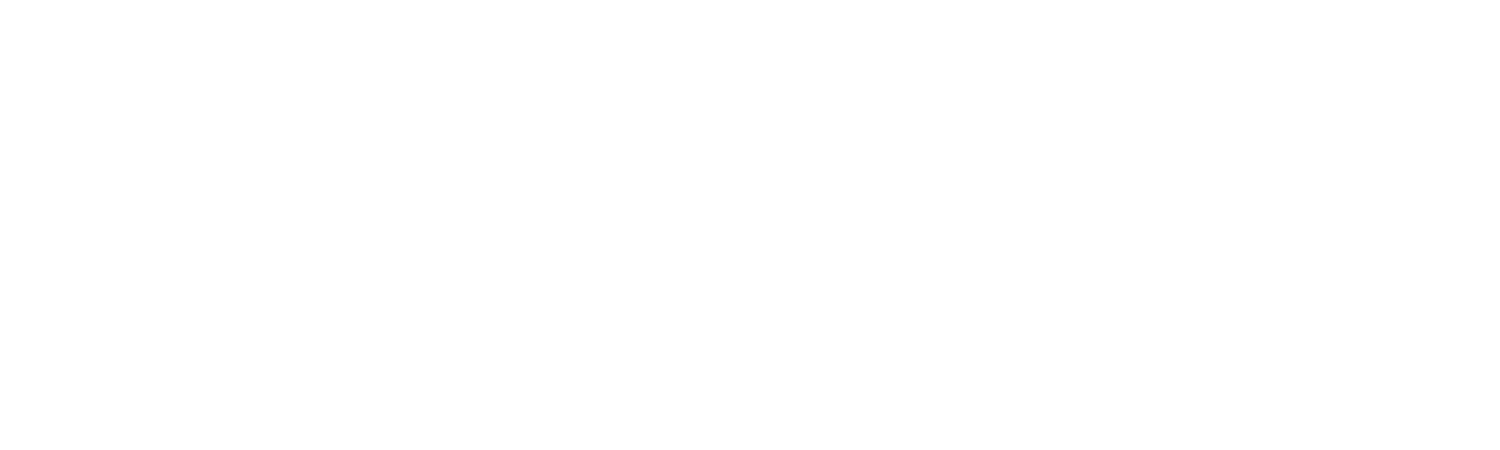

<IPython.core.display.Javascript object>


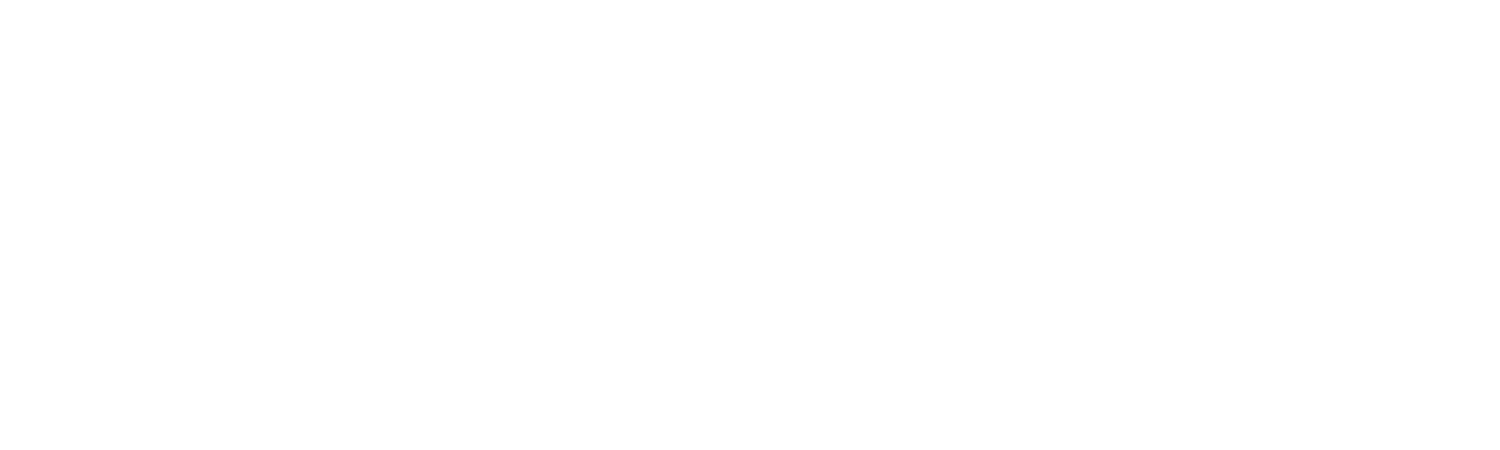

Behavior status: success
Skipping glutamate branch: no compatible SummaryLoCo/glutamate assets detected.
Skipping calcium branch: no calcium indicator detected in metadata.
Running voltage QC...


In [ ]:
status_records = []
results_by_session = {}

for asset in assets[:1]:
    print_asset_header(asset)
    asset.ensure_dirs()
    print_voltage_epoch_status(asset)
    modalities = infer_modalities(asset)
    session_key = f"{asset.subject_id}_{asset.session_id}"
    results_by_session[session_key] = {}

    # ---------------------------------------------------------------
    # Behavior / HARP / photodiode QC and time alignment
    # ---------------------------------------------------------------
    behavior_result = None
    if RUN_BEHAVIOR:
        print("Processing behavior/HARP/photodiode alignment...")
        stage = run_stage(
            "behavior",
            process_behavior_session,
            asset,
            metadata=BEHAVIOR_METADATA,
            overwrite_harp_extract=OVERWRITE_BEHAVIOR,
            overwrite_alignment=OVERWRITE_BEHAVIOR,
            save_corrected_in_place=True,
            min_epoch_duration=6.0,
            trial_gap_start=0.02,
            expected_trial_epoch_min=None,
            use_piecewise_warp=True,
            **BEHAVIOR_EPOCH_KWARGS,
        )
        behavior_result = stage["result"]
        results_by_session[session_key]["behavior"] = behavior_result
        append_record(status_records, asset, stage, extra={
            "ready_for_physiology_extraction": behavior_ready_from_result(behavior_result),
            "failure_stage": getattr(behavior_result, "failure_stage", None) if behavior_result else None,
            "failure_reasons": getattr(behavior_result, "failure_reasons", None) if behavior_result else None,
        })
        print(f"Behavior status: {stage['status']}")
        if stage.get("error"):
            print(stage["error"])

    if REQUIRE_BEHAVIOR_READY and RUN_BEHAVIOR and not behavior_ready_from_result(behavior_result):
        print("Skipping physiology extraction because behavior is not ready.")
        continue

    # ---------------------------------------------------------------
    # Glutamate QC + extraction
    # ---------------------------------------------------------------
    if modalities["glutamate"]:
        if RUN_GLUTAMATE_QC:
            print("Running SLAP2/glutamate synapse QC...")
            stage = run_stage(
                "glutamate_qc",
                run_session_synapse_qc,
                summary_mat_path=asset.summary_mat,
                output_dir=asset.qc_dir / "slap2",
                session_id=asset.session_id,
                subject_id=asset.subject_id,
                trace_signal="dF",
                trace_mode="ls",
                save=True,
                make_plots=MAKE_PLOTS,
            )
            results_by_session[session_key]["glutamate_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_GLUTAMATE_EXTRACTION:
            print("Extracting glutamate image/change/omission responses...")
            stage = run_stage(
                "glutamate_extraction",
                process_glutamate_extraction,
                asset,
                metadata=GLUTAMATE_METADATA,
                use_synapse_qc=True,
                overwrite=OVERWRITE_EXTRACTION,
                trace_signal="dFF",
                trace_mode="ls",
            )
            results_by_session[session_key]["glutamate_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping glutamate branch: no compatible SummaryLoCo/glutamate assets detected.")

    # ---------------------------------------------------------------
    # Calcium QC + extraction
    # ---------------------------------------------------------------
    if modalities["calcium"]:
        if RUN_CALCIUM_QC:
            print("Running calcium QC...")
            stage = run_stage(
                "calcium_qc",
                run_calcium_qc,
                asset,
                metadata={"im_rate_hz": FRAME_RATE_HZ},
                overwrite=OVERWRITE_QC,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
            )
            results_by_session[session_key]["calcium_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_CALCIUM_EXTRACTION:
            print("Extracting calcium image/change/omission responses...")
            stage = run_stage(
                "calcium_extraction",
                process_calcium_extraction,
                asset,
                metadata=CALCIUM_METADATA,
                use_soma_qc=True,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
                overwrite=OVERWRITE_EXTRACTION,
            )
            results_by_session[session_key]["calcium_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping calcium branch: no calcium indicator detected in metadata.")

    # ---------------------------------------------------------------
    # Voltage QC + extraction
    # ---------------------------------------------------------------
    if modalities["voltage"]:
        if RUN_VOLTAGE_QC:
            print("Running voltage QC...")
            stage = run_stage(
                "voltage_qc",
                run_voltage_qc,
                asset,
                overwrite=OVERWRITE_QC,
                **voltage_qc_kwargs_for_asset(asset),
            )
            results_by_session[session_key]["voltage_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Voltage QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_VOLTAGE_EXTRACTION:
            for trace_signal in VOLTAGE_TRACE_SIGNALS:
                print(f"Extracting voltage responses: {trace_signal}...")
                stage = run_stage(
                    f"voltage_extraction_{trace_signal}",
                    process_voltage_extraction,
                    asset,
                    trace_signal=trace_signal,
                    overwrite=OVERWRITE_EXTRACTION,
                    **voltage_extraction_kwargs_for_asset(asset),
                )
                results_by_session[session_key][f"voltage_extraction_{trace_signal}"] = stage["result"]
                append_record(status_records, asset, stage, extra={"trace_signal": trace_signal})
                print(f"Voltage extraction {trace_signal} status: {stage['status']}")
                if stage.get("error"):
                    print(stage["error"])
    else:
        if modalities["voltage_by_indicator_without_files"]:
            print("Metadata suggests voltage indicator, but voltage summary/H5 files were not detected.")
        else:
            print("Skipping voltage branch: no voltage extraction assets detected.")

status_df = pd.DataFrame(status_records)
display(status_df)

## 7. Save and summarize processing status

This produces a timestamp-free status CSV in the current working directory. Change `STATUS_CSV` if you want it saved elsewhere.


In [ ]:
STATUS_CSV = Path("vip_sd_processing_status.csv")

if "status_df" in globals() and not status_df.empty:
    status_df.to_csv(STATUS_CSV, index=False)
    print(f"Saved status table to: {STATUS_CSV.resolve()}")

    summary = (
        status_df
        .groupby(["stage", "status"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["stage", "status"])
    )
    display(summary)
else:
    print("No status records yet. Run the main batch-processing loop first.")

## 8. Inspect voltage dF/F for one ROI

Use this section after `process_voltage_extraction(..., write_session_traces=True)` has produced a `voltage_session_traces_*.h5` file.

The full-session H5 contains `/DMD#/raw_f`, `/DMD#/f0`, and `/DMD#/dff`, all shaped as `(n_rois, n_samples)`. This lets you look at raw fluorescence, the F0 model, and normalized ASAP-polarity-corrected dF/F without rerunning MATLAB extraction.


In [ ]:
# Pick a voltage session and ROI to inspect.
# This cell uses the saved transform file produced by process_voltage_extraction.

voltage_assets = [a for a in assets if infer_modalities(a)["voltage"]]

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[0]
    dmd = 1
    roi_index = 0
    trace_signal = "dff_robust_f0"
    trace_mode = resolve_voltage_trace_mode(asset)

    session_trace_h5 = asset.derived_subdir("voltage", create=False) / f"voltage_session_traces_{trace_signal}_{trace_mode}.h5"
    print("Inspecting:", session_trace_h5)

    if not session_trace_h5.exists():
        print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
    else:
        roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
        t = roi["timebase_sec"]
        raw_f = roi["raw_f"]
        f0 = roi["f0"]
        # Use the stored ASAP-polarity-corrected dFF. Do not recompute as (raw_f - f0) / f0.
        # The voltage pipeline defines positive ASAP dFF as (F0 - F) / F0.
        dff = roi["dff"]

        recon_meta = roi.get("reconstruction_metadata", {})
        if recon_meta:
            print("Reconstruction metadata:")
            display(pd.Series(recon_meta))

        fig, ax = plt.subplots(figsize=(15, 4))
        ax.plot(t, raw_f, lw=0.4, label="raw F")
        ax.plot(t, f0, lw=1.0, label="F0")
        ax.set_xlabel("Corrected behavior time (s)")
        ax.set_ylabel("Fluorescence")
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | raw F and F0")
        ax.legend()
        plt.show()

        fig, ax = plt.subplots(figsize=(15, 4))
        ax.plot(t, dff, lw=0.4)
        ax.set_xlabel("Corrected behavior time (s)")
        ax.set_ylabel("dFF = (F0 - F) / F0")
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | ASAP7y dFF")
        plt.show()


## 9. Compute one voltage ROI transform on the fly

This is useful before committing to batch F0 settings. It reconstructs the full ROI trace from the session asset, estimates either static or robust F0, and returns `raw_f`, `f0`, and `dff` for visualization.


In [ ]:
# Compute one ROI transform without running full event extraction.

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[0]
    dmd = 1
    roi_index = 0

    roi = compute_voltage_roi_transform_from_asset(
        asset,
        dmd=dmd,
        roi_index=roi_index,
        sample_rate_hz=VOLTAGE_SAMPLE_RATE_HZ,
        default_sample_rate_hz=VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
        trace_mode=resolve_voltage_trace_mode(asset),
        timebase_strategy=VOLTAGE_TIMEBASE_STRATEGY,
        max_timebase_error_sec=VOLTAGE_MAX_TIMEBASE_ERROR_SEC,
        f0_method="robust",       # "static" or "robust"
        f0_percentile=50.0,
        robust_f0_bin_sec=5.0,
        robust_f0_smooth_sec=180.0,
    )

    t = roi["timebase_sec"]
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]

    recon_meta = roi.get("reconstruction_metadata", {})
    if recon_meta:
        print("Reconstruction metadata:")
        display(pd.Series(recon_meta))

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(t, raw_f, lw=0.4, label="raw F")
    ax.plot(t, f0, lw=1.0, label="F0")
    ax.set_xlabel("Corrected behavior time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title(f"On-the-fly F0 check | {asset.session_id} | DMD{dmd} ROI {roi_index}")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(t, dff, lw=0.4)
    ax.set_xlabel("Corrected behavior time (s)")
    ax.set_ylabel("dFF = (F0 - F) / F0")
    ax.set_title("On-the-fly ASAP-polarity-corrected dFF")
    plt.show()


## 10. Expected output folders

For a fully processed session, outputs should look like:

```text
analysis/qc/behavior/
analysis/qc/slap2/              # glutamate synapse QC
analysis/qc/glutamate/
analysis/qc/calcium/
analysis/qc/voltage/
analysis/derived/glutamate/
analysis/derived/calcium/
analysis/derived/voltage/
```

For voltage, the key full-session transform output is:

```text
analysis/derived/voltage/voltage_session_traces_dff_static_f0_trial.h5
analysis/derived/voltage/voltage_session_traces_dff_robust_f0_trial.h5
```

Each contains `raw_f`, `f0`, and `dff`, enabling later reinspection of the F0 model and full-session ROI voltage dynamics.


In [ ]:
from vip_slap2_analysis.voltage.summary import VoltageSummary

In [ ]:
temp_path = 